In [1]:
import pandas as pd
import os
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker 
import json
from B_template import  scale_array, inverse_scale_array,  process_predictions, compute_metrics, compute_error, make_windows_autoregressive

In [2]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import time
from tensorflow.keras import layers, models, initializers

def tensorflow_dense(X_train_scaled, Y_train_scaled, X_validation_scaled, Y_validation_scaled, 
                       learning_rate, target_MAE, jumlah_epochs, jumlah_sampel_batch,
                       jumlah_epoch_terbelakang, save_best_model_path, validation_data=False, load_model=None):
    global model

    class MAEStopCallback(tf.keras.callbacks.Callback):
        def __init__(self, threshold):
            super(MAEStopCallback, self).__init__()
            self.threshold = threshold

        def on_epoch_end(self, epoch, logs=None):
            # Print logs every 50 epochs (epoch is 0-indexed)
            if (epoch + 1) % 50 == 0:
                mae = logs.get('mae')
                val_mae = logs.get('val_mae', 'N/A')
                print(f"Epoch {epoch + 1}: MAE = {mae:.4f}, Val MAE = {val_mae}")

            # Your existing stop logic
            if logs['mae'] < self.threshold:
                print(f"\nMAE reached below {self.threshold}. Stopping training.")
                self.model.stop_training = True

    # Mendapatkan dimensi input
    input_width = X_train_scaled.shape[1]   #  timestep input
    num_features = X_train_scaled.shape[2]    # jumlah fitur 
    forecast_horizon = Y_train_scaled.shape[1]  # 1 timestep output

    model = tf.keras.models.Sequential()
    if load_model is None:
        model.add(tf.keras.layers.Input(shape=(input_width, num_features)))
        model.add(layers.LSTM(
        units=48*2,
        return_sequences=False,
        kernel_initializer=initializers.GlorotUniform(seed=10),
        recurrent_initializer=initializers.Orthogonal(seed=10),
        bias_initializer=initializers.Zeros()
    ))

        model.add(layers.Dense(
            units=forecast_horizon,
            activation='linear',
            kernel_initializer=initializers.GlorotUniform(seed=10),
            bias_initializer=initializers.Zeros()
        ))



    else:
        model = tf.keras.models.load_model(load_model)
    
    model.summary()
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mse', 'mae', tf.keras.metrics.MeanAbsolutePercentageError(name='mape')])
    mae_stop_callback = MAEStopCallback(threshold=target_MAE)

    checkpoint_callback = ModelCheckpoint(
        save_best_model_path,
        monitor='val_mse',
        mode='min',
        save_best_only=True,
        verbose=False
    )

    early_stopping_callback = EarlyStopping(
        monitor='val_mse',
        mode='min',
        patience=jumlah_epoch_terbelakang,
        restore_best_weights=True,
        verbose=False
    )

    time_start = time.time()
    if validation_data:
        model.fit(X_train_scaled, Y_train_scaled, epochs=jumlah_epochs, batch_size=jumlah_sampel_batch,  
                  callbacks=[mae_stop_callback, checkpoint_callback, early_stopping_callback],
                  validation_data=(X_validation_scaled, Y_validation_scaled), validation_batch_size=jumlah_sampel_batch,
                  verbose=False)
    else:
        model.fit(X_train_scaled, Y_train_scaled, epochs=jumlah_epochs, batch_size=jumlah_sampel_batch, 
                  callbacks=[mae_stop_callback, checkpoint_callback, early_stopping_callback],
                  verbose=False)
    
    print("Time computation seconds: ", time.time() - time_start)
    
    loss, MSE, MAE, MAPE = model.evaluate(X_train_scaled, Y_train_scaled)
    print("Loss:", loss, "MSE:", MSE, "MAE:", MAE, "MAPE:", MAPE)
    
    return model, loss, MSE, MAE,  MAPE



Memproses Hari: senin
Path training data: d:\satwika_bintang\CODE\TIMESERIES-master\PER_HARI\DATA_HARI\data_senin_train.xlsx
Computed orig_min: 13475.0
Computed orig_max: 32091.171875
Path validation data: d:\satwika_bintang\CODE\TIMESERIES-master\PER_HARI\DATA_HARI\data_senin_testing.xlsx
Running step (window size): 24
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 96)                37632     
                                                                 
 dense (Dense)               (None, 48)                4656      
                                                                 
Total params: 42,288
Trainable params: 42,288
Non-trainable params: 0
_________________________________________________________________
Epoch 50: MAE = 0.1063, Val MAE = 0.1278713345527649
Time computation seconds:  84.25108408927917
220/220 [==================

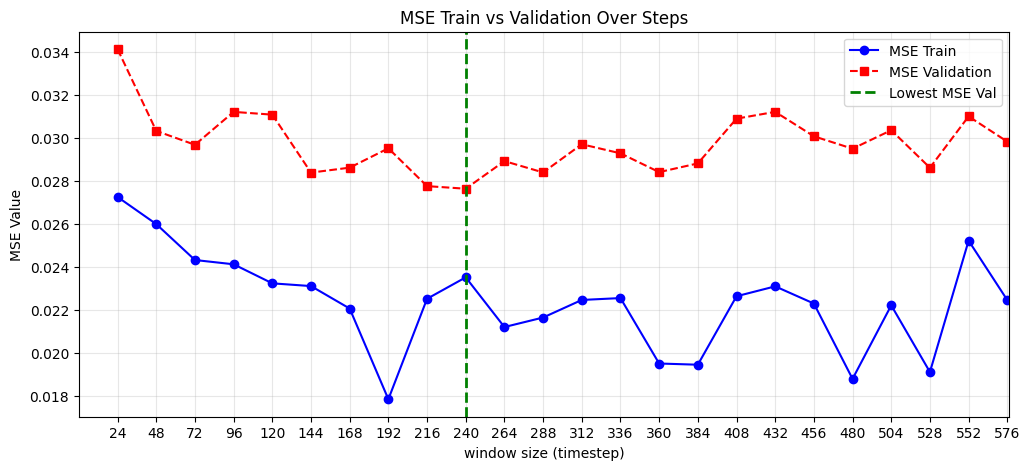

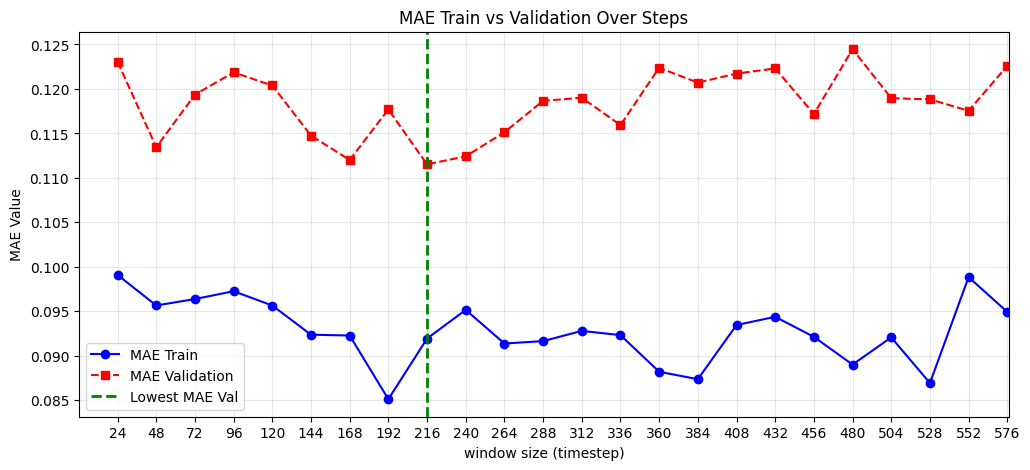


Memproses Hari: selasa
Path training data: d:\satwika_bintang\CODE\TIMESERIES-master\PER_HARI\DATA_HARI\data_selasa_train.xlsx
Computed orig_min: 14727.0
Computed orig_max: 32638.990234375
Path validation data: d:\satwika_bintang\CODE\TIMESERIES-master\PER_HARI\DATA_HARI\data_selasa_testing.xlsx
Running step (window size): 24
Model: "sequential_24"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_24 (LSTM)              (None, 96)                37632     
                                                                 
 dense_24 (Dense)            (None, 48)                4656      
                                                                 
Total params: 42,288
Trainable params: 42,288
Non-trainable params: 0
_________________________________________________________________
Epoch 50: MAE = 0.0904, Val MAE = 0.11649978905916214
Epoch 100: MAE = 0.0838, Val MAE = 0.11258883774280548
Epoch 1

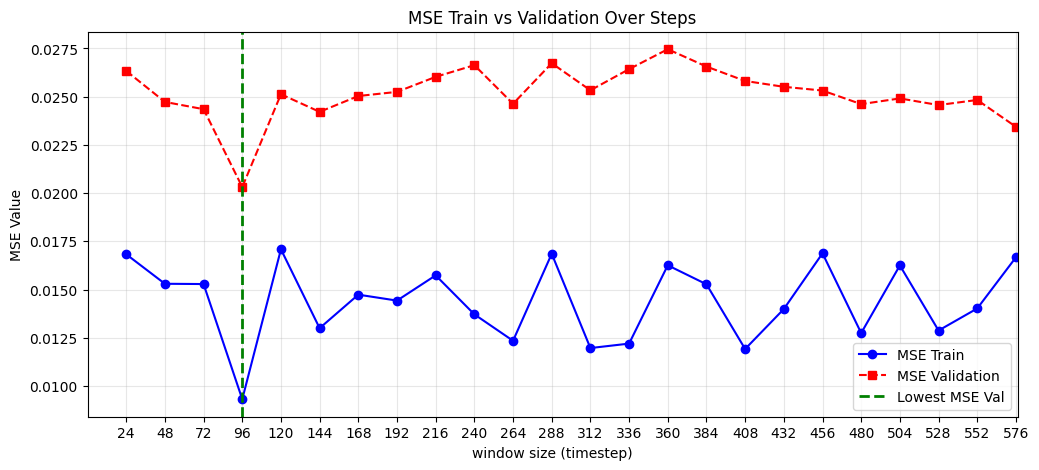

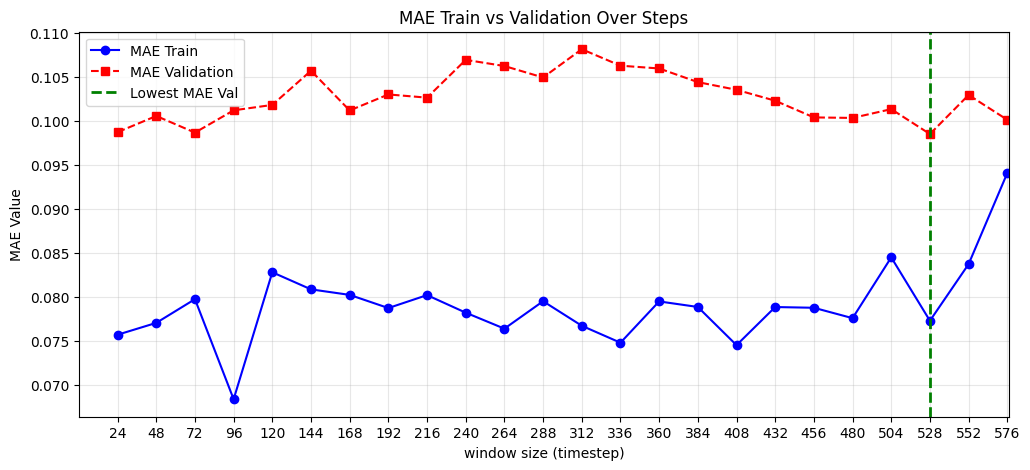


Memproses Hari: rabu
Path training data: d:\satwika_bintang\CODE\TIMESERIES-master\PER_HARI\DATA_HARI\data_rabu_train.xlsx
Computed orig_min: 15090.8701171875
Computed orig_max: 32758.619140625
Path validation data: d:\satwika_bintang\CODE\TIMESERIES-master\PER_HARI\DATA_HARI\data_rabu_testing.xlsx
Running step (window size): 24
Model: "sequential_48"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_48 (LSTM)              (None, 96)                37632     
                                                                 
 dense_48 (Dense)            (None, 48)                4656      
                                                                 
Total params: 42,288
Trainable params: 42,288
Non-trainable params: 0
_________________________________________________________________
Epoch 50: MAE = 0.1034, Val MAE = 0.12775525450706482
Epoch 100: MAE = 0.0977, Val MAE = 0.12070915102958679
Time

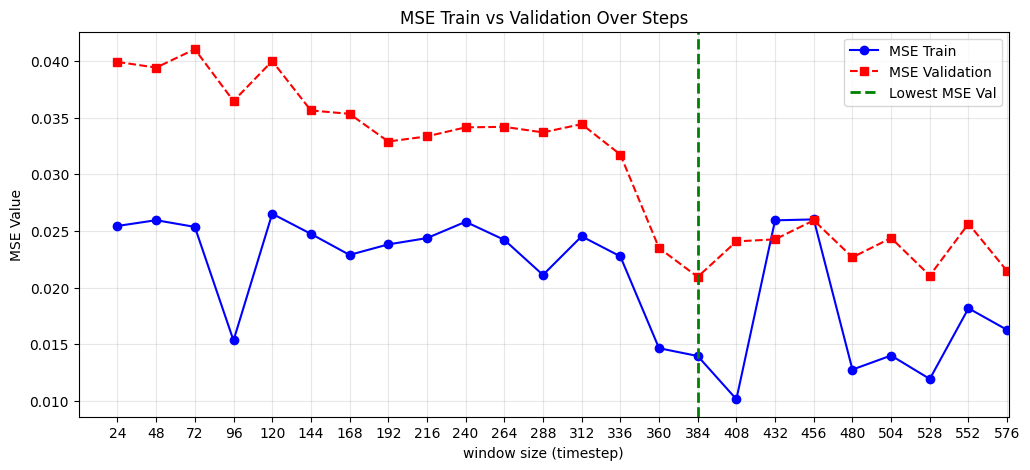

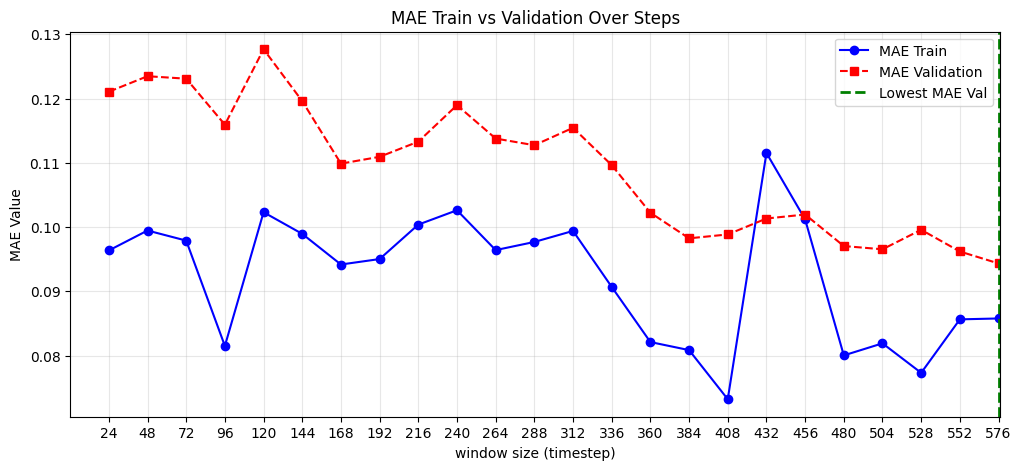


Memproses Hari: kamis
Path training data: d:\satwika_bintang\CODE\TIMESERIES-master\PER_HARI\DATA_HARI\data_kamis_train.xlsx
Computed orig_min: 15529.0
Computed orig_max: 32423.69921875
Path validation data: d:\satwika_bintang\CODE\TIMESERIES-master\PER_HARI\DATA_HARI\data_kamis_testing.xlsx
Running step (window size): 24
Model: "sequential_72"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_72 (LSTM)              (None, 96)                37632     
                                                                 
 dense_72 (Dense)            (None, 48)                4656      
                                                                 
Total params: 42,288
Trainable params: 42,288
Non-trainable params: 0
_________________________________________________________________
Epoch 50: MAE = 0.1225, Val MAE = 0.139387845993042
Epoch 100: MAE = 0.1160, Val MAE = 0.12999998033046722
Epoch 150: MA

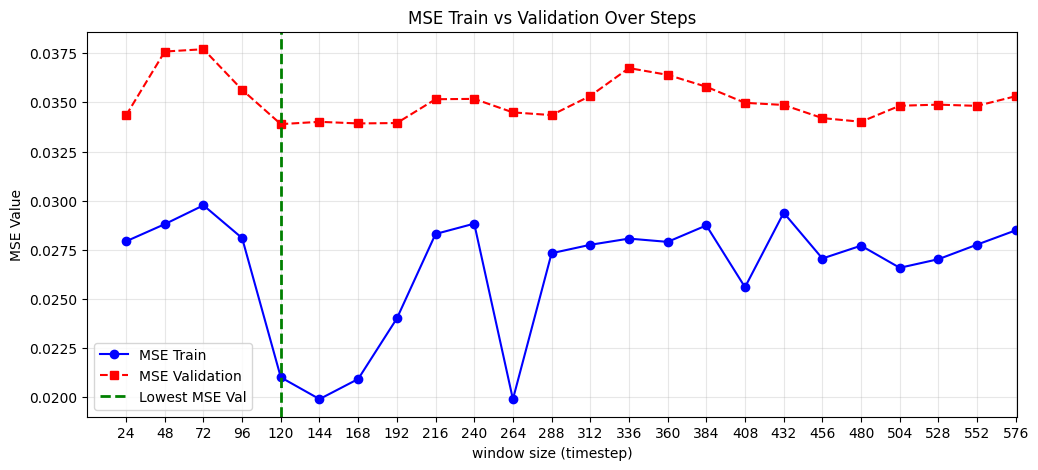

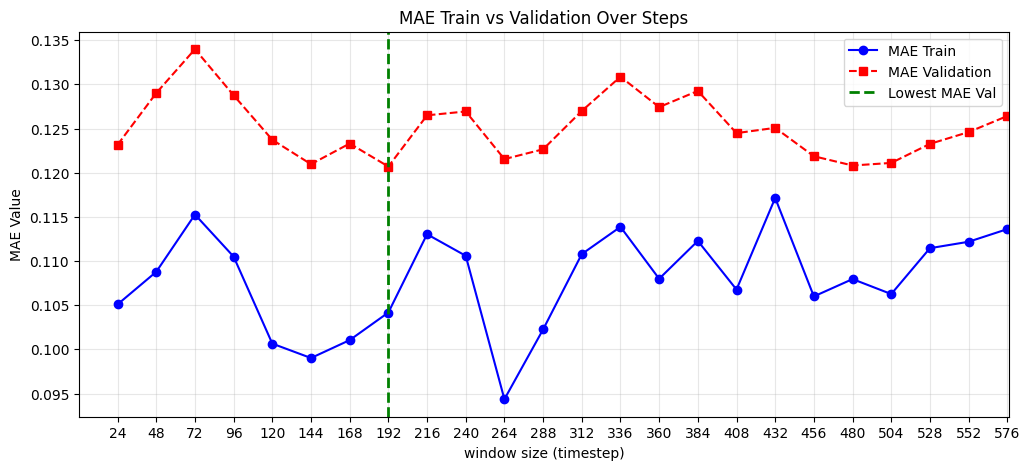


Memproses Hari: jumat
Path training data: d:\satwika_bintang\CODE\TIMESERIES-master\PER_HARI\DATA_HARI\data_jumat_train.xlsx
Computed orig_min: 15580.8798828125
Computed orig_max: 32387.19921875
Path validation data: d:\satwika_bintang\CODE\TIMESERIES-master\PER_HARI\DATA_HARI\data_jumat_testing.xlsx
Running step (window size): 24
Model: "sequential_96"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_96 (LSTM)              (None, 96)                37632     
                                                                 
 dense_96 (Dense)            (None, 48)                4656      
                                                                 
Total params: 42,288
Trainable params: 42,288
Non-trainable params: 0
_________________________________________________________________
Time computation seconds:  42.332865476608276
219/219 [==============================] - 0s 2ms/step - loss: 0.

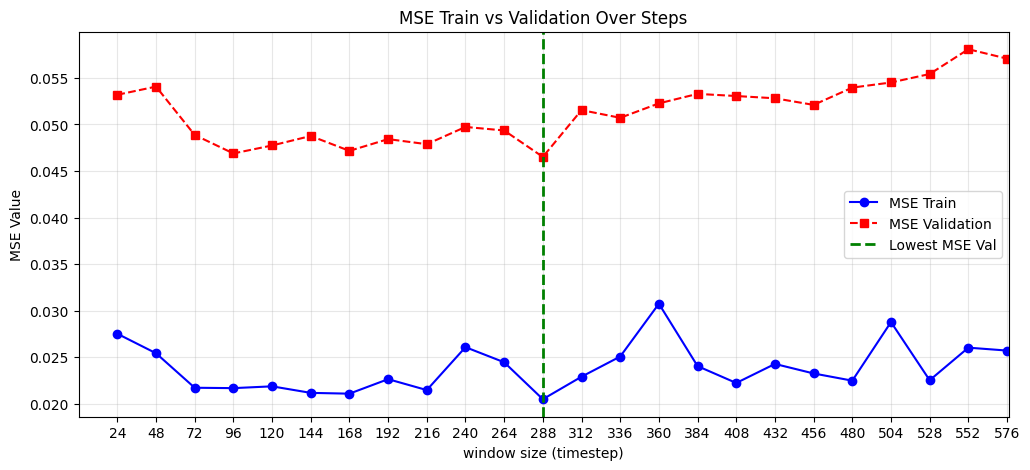

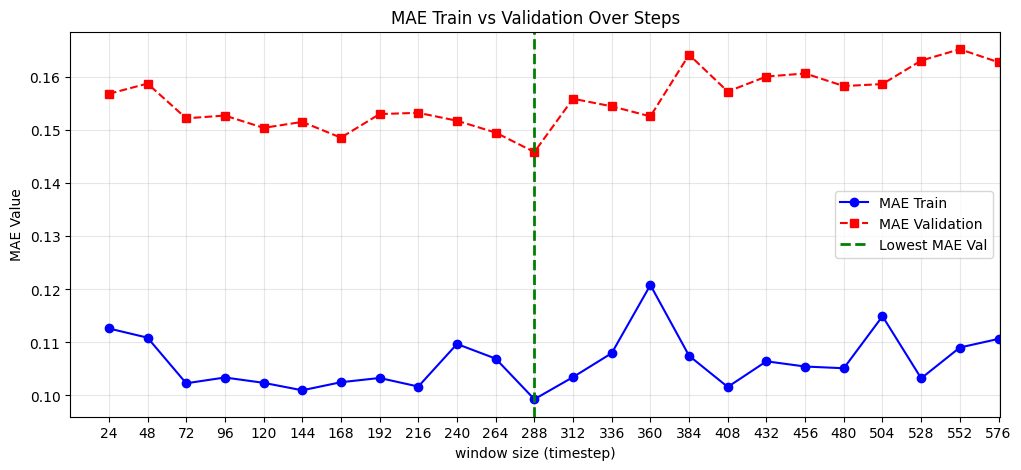


Memproses Hari: sabtu
Path training data: d:\satwika_bintang\CODE\TIMESERIES-master\PER_HARI\DATA_HARI\data_sabtu_train.xlsx
Computed orig_min: 14280.7197265625
Computed orig_max: 30450.240234375
Path validation data: d:\satwika_bintang\CODE\TIMESERIES-master\PER_HARI\DATA_HARI\data_sabtu_testing.xlsx
Running step (window size): 24
Model: "sequential_120"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_120 (LSTM)             (None, 96)                37632     
                                                                 
 dense_120 (Dense)           (None, 48)                4656      
                                                                 
Total params: 42,288
Trainable params: 42,288
Non-trainable params: 0
_________________________________________________________________
Epoch 50: MAE = 0.1070, Val MAE = 0.12195231020450592
Time computation seconds:  93.73124361038208
219/219 [=

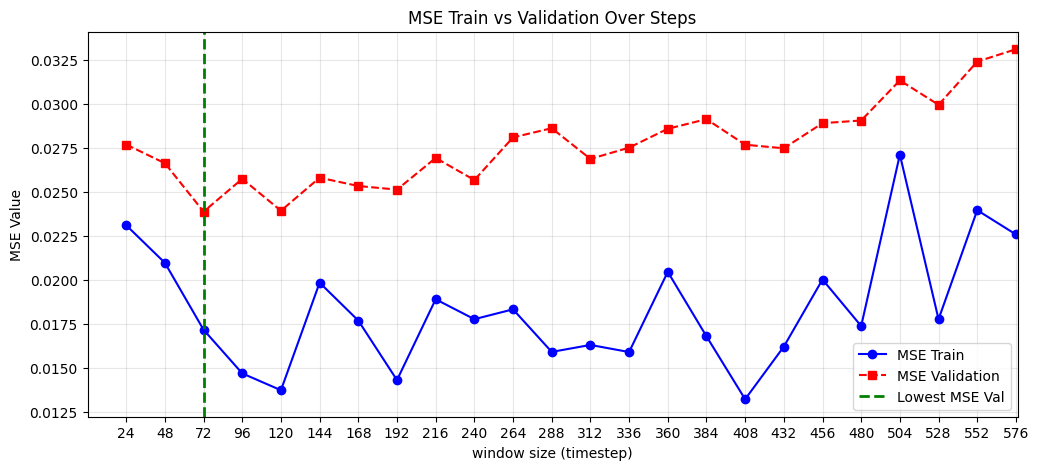

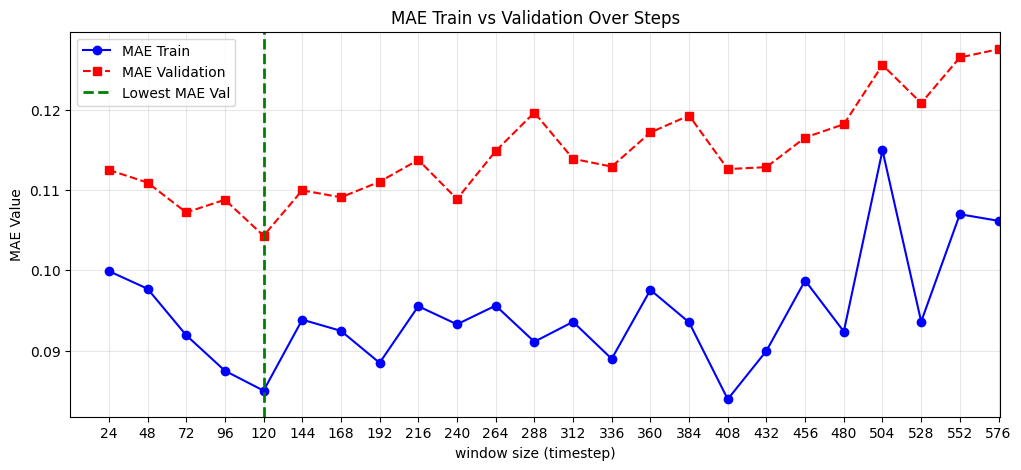


Memproses Hari: minggu
Path training data: d:\satwika_bintang\CODE\TIMESERIES-master\PER_HARI\DATA_HARI\data_minggu_train.xlsx
Computed orig_min: 14911.0
Computed orig_max: 28698.919921875
Path validation data: d:\satwika_bintang\CODE\TIMESERIES-master\PER_HARI\DATA_HARI\data_minggu_testing.xlsx
Running step (window size): 24
Model: "sequential_144"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_144 (LSTM)             (None, 96)                37632     
                                                                 
 dense_144 (Dense)           (None, 48)                4656      
                                                                 
Total params: 42,288
Trainable params: 42,288
Non-trainable params: 0
_________________________________________________________________
Epoch 50: MAE = 0.0995, Val MAE = 0.11723334342241287
Epoch 100: MAE = 0.0888, Val MAE = 0.10490172356367111
Time c

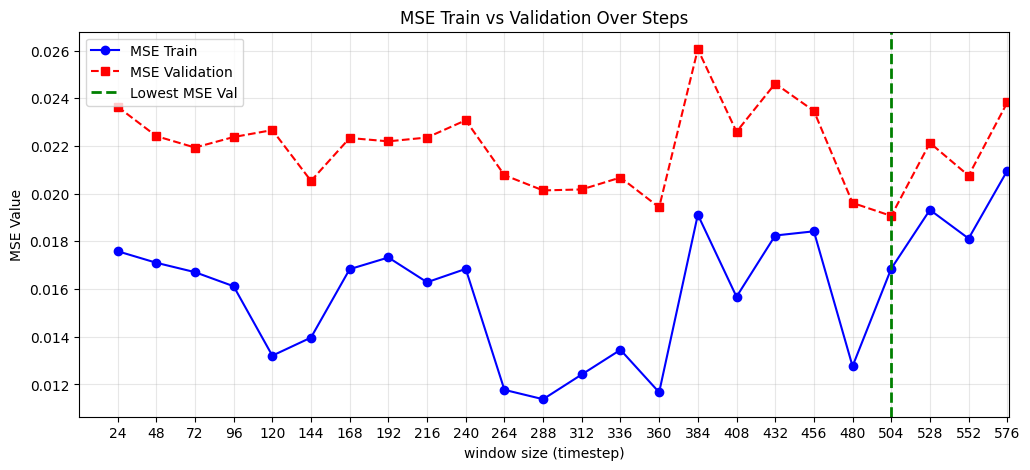

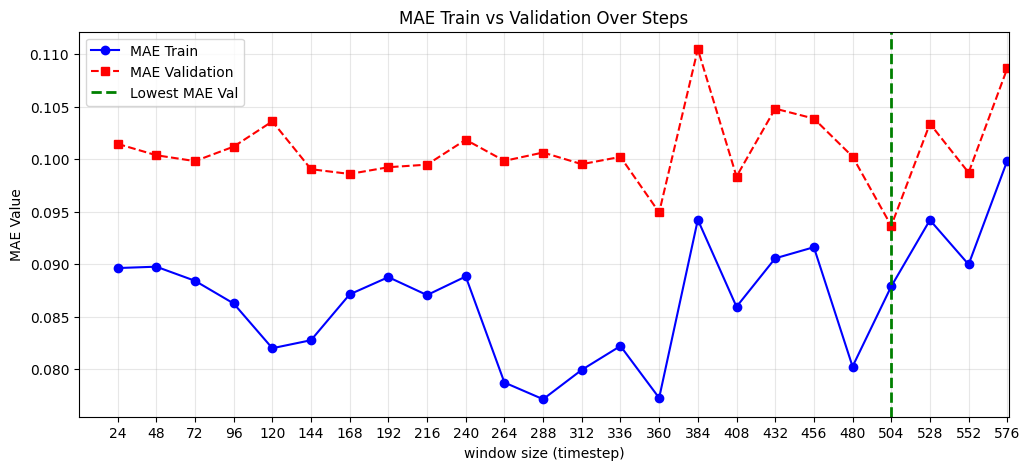

In [3]:
def setup_gpu_memory():
    """Mengatur pertumbuhan memori GPU agar tidak langsung mengambil semua VRAM."""
    physical_devices = tf.config.list_physical_devices('GPU')
    if physical_devices:
        try:
            for device in physical_devices:
                tf.config.experimental.set_memory_growth(device, True)
        except RuntimeError as e:
            print(e)

def plot_metrics(metric_dict, start_step, end_step, step_slice, metric_name="MSE"):
    """Fungsi untuk membuat grafik evaluasi training vs validation."""
    data_train = metric_dict[f"{metric_name}_train"]
    data_val = metric_dict[f"{metric_name}_val"]
    x_values = np.arange(start_step, end_step + 1, step_slice)

    plt.figure(figsize=(12, 5))
    plt.plot(x_values, data_train, marker='o', linestyle='-', color='b', label=f"{metric_name} Train")
    plt.plot(x_values, data_val, marker='s', linestyle='--', color='r', label=f"{metric_name} Validation")
    
    # Menandai titik terendah pada data validasi
    min_idx = np.argmin(data_val)
    plt.axvline(x=x_values[min_idx], color='g', linestyle='--', linewidth=2, label=f"Lowest {metric_name} Val")
    
    plt.xlabel("window size (timestep)")
    plt.ylabel(f"{metric_name} Value")
    plt.title(f"{metric_name} Train vs Validation Over Steps")
    plt.xticks(np.arange(start_step, end_step + 100, 24), fontsize=10)
    plt.yticks(fontsize=10)
    plt.xlim(0, end_step + 1)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def train_daily_model(master_folder, hari_array=None):
    """Fungsi utama untuk memproses data dan melatih model per hari."""
    if hari_array is None:
        hari_array = ['senin', 'selasa', 'rabu', 'kamis', 'jumat', 'sabtu', 'minggu']
    
    setup_gpu_memory()

    for hari in hari_array:
        print(f"\n{'='*30}\nMemproses Hari: {hari}\n{'='*30}")
        
        # 1. Load dan Preprocessing Data Training
        path_train_data = os.path.join(master_folder, 'DATA_HARI', f'data_{hari}_train.xlsx')
        print(f"Path training data: {path_train_data}")
        
        data_training_awal = pd.read_excel(path_train_data, index_col=0)
        data_training = data_training_awal[['Beban']].astype('float32').copy()
        
        # Normalisasi training
        data_training['Beban'], min_beban, max_beban = scale_array(
            data_training['Beban'].values, 
            new_min=-1, 
            new_max=1
        )

        # 2. Load dan Preprocessing Data Testing
        path_validation_data = os.path.join(master_folder, 'DATA_HARI', f'data_{hari}_testing.xlsx')
        print(f"Path validation data: {path_validation_data}")
        
        data_validation_awal = pd.read_excel(path_validation_data, index_col=0)
        data_validation = data_validation_awal[['Beban']].astype('float32').copy()

        # Normalisasi testing menggunakan parameter dari training
        data_validation['Beban'], _, _ = scale_array(
            data_validation['Beban'].values, 
            new_min=-1, 
            new_max=1,
            orig_min=min_beban,
            orig_max=max_beban
        )

        # Persiapan array untuk windowing
        input_train = data_training.to_numpy()
        output_train = data_training['Beban'].to_numpy()
        input_val = data_validation.to_numpy()
        output_val = data_validation['Beban'].to_numpy()

        # 3. Iterasi Window Size (Steps)
        metric_dict = {
            "MSE_train": [], "MAE_train": [], "MAPE_train": [], 
            "MSE_val": [], "MAE_val": [], "MAPE_val": []
        }
        
        start_step = 24
        step_slice = 24
        end_step = 24 * 24
        loss_val_before = float('inf')

        for step in range(start_step, end_step + 1, step_slice):
            print(f"Running step (window size): {step}")
            
            input_width = step
            label_width = 48
            
            # Membuat windows
            x_train, y_train = make_windows_autoregressive(input_train, output_train, input_width, label_width)
            x_val, y_val = make_windows_autoregressive(input_val, output_val, input_width, label_width)
            
            save_weight_path = f"SAVED_LSTM\\model_{hari}_step_{step}.h5"
            model=None
            # Proses training model
            model, loss, MSE, MAE, MAPE = tensorflow_dense(
                x_train, y_train, x_val, y_val, 
                learning_rate=0.0001, 
                target_MAE=0.0001, 
                jumlah_epochs=200, 
                jumlah_sampel_batch=24, 
                jumlah_epoch_terbelakang=15, 
                save_best_model_path=save_weight_path, 
                validation_data=True, 
                load_model=None
            )
            
            # Evaluasi model terbaik yang baru saja disimpan
            model.load_weights(save_weight_path)
            loss_val, MSE_val, MAE_val, MAPE_val = model.evaluate(x_val, y_val, verbose=0)
            
            # Simpan metrics
            metric_dict["MSE_train"].append(float(MSE))
            metric_dict["MAE_train"].append(float(MAE))
            metric_dict["MAPE_train"].append(float(MAPE))
            metric_dict["MSE_val"].append(float(MSE_val))
            metric_dict["MAE_val"].append(float(MAE_val))
            metric_dict["MAPE_val"].append(float(MAPE_val))

            # Simpan log ke JSON
            json_file_path = f"SAVED_LSTM\\metrics_{hari}_step{step}.json"
            with open(json_file_path, 'w') as json_file:
                json.dump(metric_dict, json_file)

            # Update model terbaik secara keseluruhan untuk hari tersebut
            if loss_val < loss_val_before:
                loss_val_before = loss_val
                model.save(f"SAVED_LSTM\\best_model_{hari}.h5")
                print(f"New best model saved for {hari} at step {step}")

        # 4. Plotting Hasil untuk hari tersebut
        plot_metrics(metric_dict, start_step, end_step, step_slice, "MSE")
        plot_metrics(metric_dict, start_step, end_step, step_slice, "MAE")

# --- Cara Penggunaan ---
master_folder_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
train_daily_model(master_folder_path)

In [4]:
# import json
# tf.config.experimental.set_memory_growth
# # Get the directory of the current file
# current_path = os.getcwd()

# # Go up two levels to reach TIMESERIES-MASTER
# master_folder = os.path.abspath(os.path.join(current_path, ".."))

# print(f"Master folder path: {master_folder}")
# hari_array= ['senin','selasa','rabu','kamis','jumat','sabtu','minggu']
# for hari_index, hari in enumerate(hari_array):
#     #import data training per Hari
#     path_train_data = os.path.join(master_folder, 'DATA_HARI\\data_%s_train.xlsx'%hari_array[hari_index])
#     print("path training data", path_train_data)
#     data_training_awal = pd.read_excel(path_train_data, index_col=0)
#     data_training= data_training_awal.astype('float32').copy()
#     data_training = data_training[['Beban']].copy()
#     # normalisasi training
#     data_training['Beban'], min_beban, max_beban = scale_array(
#         data_training['Beban'].values, 
#         new_min=-1, 
#         new_max=1)
#     print("data_training:", data_training)



#     #import data testing per Hari
#     path_validation_data = os.path.join(master_folder, 'DATA_HARI\\data_%s_testing.xlsx'%hari_array[hari_index])
#     print("path validation data", path_validation_data)
#     data_validation_awal= pd.read_excel(path_validation_data, index_col=0)
#     data_validation= data_validation_awal.astype('float32').copy()
#     data_validation = data_validation[['Beban']].copy()

#     # normalisasi testing
#     data_validation['Beban'], _, _ = scale_array(
#         data_validation['Beban'].values, 
#         new_min=-1, 
#         new_max=1,
#         orig_min=min_beban,
#         orig_max=max_beban
#     )
#     print("data_validation", data_validation)


#     input_make_windows      =   data_training.to_numpy()
#     output_make_windows     =   data_training['Beban'].to_numpy()
#     input_make_windows_validation   = data_validation.to_numpy()
#     output_make_windows_validation  = data_validation['Beban'].to_numpy()

#     # training
#     metric_dict={"MSE_train":[], "MAE_train": [],  "MAPE_train": [], "MSE_val":[], "MAE_val": [],  "MAPE_val": []}
#     start_step=24
#     step_slice=24
#     end_step=int(24*24)
#     loss_val_before=1000000
#     for step in range(start_step,1+end_step, step_slice):
#         model=None
#         print("step: ", step)
#         input_width = step
#         label_width = 48
#         shift = label_width
#         total_window_size = input_width + shift
#         OUT_STEPS = label_width
#         # Definisikan irisan untuk input dan label
#         input_slice = slice(0, input_width)
#         label_start = total_window_size - label_width
#         labels_slice = slice(label_start, None)
#         x_train,    y_train     =  make_windows_autoregressive(input_make_windows, output_make_windows, input_width, label_width)
#         x_val,  y_val                   = make_windows_autoregressive(input_make_windows_validation, output_make_windows_validation, input_width, label_width)
#         print(x_train.shape, y_train.shape, x_val.shape, y_val.shape)
#         save_weight_path="model%s.h5"%step
#         model, loss, MSE, MAE, MAPE= tensorflow_dense(x_train, y_train, x_val, y_val, learning_rate=0.0001, target_MAE=0.0001,  jumlah_epochs=200, jumlah_sampel_batch=24, 
#                                                         jumlah_epoch_terbelakang=15,  save_best_model_path = save_weight_path, 
#                                                         validation_data=True, load_model=None)
    
#         model.load_weights(save_weight_path)
#         loss_val, MSE_val, MAE_val, MAPE_val = model.evaluate(x_val, y_val)
#         print("Loss_val:", loss_val, "MSE_val:", MSE_val, "MAE_val:", MAE_val, "MAPE_val:", MAPE_val)
#         metric_dict["MSE_train"].append(MSE)
#         metric_dict["MAE_train"].append(MAE)
#         metric_dict["MAPE_train"].append(MAPE)
#         metric_dict["MSE_val"].append(MSE_val)
#         metric_dict["MAE_val"].append(MAE_val)
#         metric_dict["MAPE_val"].append(MAPE_val)

#         # Simpan json dictinary ke file
#         json_file_path = f"metrics_eval{step}.json"
#         with open(json_file_path, 'w+') as json_file:
#             json.dump(metric_dict, json_file)
#         if loss_val< loss_val_before:
#             loss_val_before=loss_val
#             model.save("best_model.h5")
#             print("Model saved as best_model.h5")
#         print() 
    
    
    
#     # Di luar loop training
#     # Extract data
#     data_train = metric_dict["MSE_train"]
#     data_val = metric_dict["MSE_val"]

#     # Generate x-values dynamically
#     x_values = np.arange(start_step, end_step+1, step_slice)

#     # Plot
#     plt.figure(figsize=(12, 5))
#     plt.plot(x_values, data_train, marker='o', linestyle='-', color='b', label="MSE Train")
#     plt.plot(x_values, data_val, marker='s', linestyle='--', color='r', label="MSE Validation")
#     plt.axvline(x=(np.argmin(data_val)+1)*step_slice, color='g', linestyle='--', linewidth=2, label="Lowest MSE Validation")
#     # Labels
#     plt.xlabel("window size (timestep)")
#     plt.ylabel("MSE Value")
#     plt.title("MSE Train vs Validation Over Steps")
#     plt.xticks(np.arange(12,end_step+999, 24),fontsize=12)
#     plt.yticks(fontsize=12)
#     plt.xlim(0, end_step+1)
#     plt.legend()

#     # Show plot
#     plt.show()

#     # Extract data
#     data_train = metric_dict["MAE_train"]
#     data_val = metric_dict["MAE_val"]

#     # Generate x-values dynamically
#     x_values = np.arange(start_step, end_step+1, step_slice)

#     # Plot
#     plt.figure(figsize=(12, 5))
#     plt.plot(x_values, data_train, marker='o', linestyle='-', color='b', label="MAE Train")
#     plt.plot(x_values, data_val, marker='s', linestyle='--', color='r', label="MAE Validation")
#     plt.axvline(x=(np.argmin(data_val)+1)*step_slice, color='g', linestyle='--', linewidth=2, label="Lowest MSE Validation")
#     # Labels
#     plt.xlabel("window size (timestep)")
#     plt.ylabel("MAE Value")
#     plt.title("MAE Train vs Validation Over Steps")
#     plt.xticks(np.arange(12,end_step+999, 24),fontsize=12)
#     plt.yticks(fontsize=12)
#     plt.xlim(0, end_step+1)
#     plt.legend()

#     # Show plot
#     plt.show()


    